In [4]:
from google.colab import drive
drive.mount('/content/drive')

import polars as pl

file_path = '/content/drive/MyDrive/Amazon_Musical/Musical_Instruments.jsonl'

try:
    df_polars = pl.read_ndjson(file_path)
    print(df_polars.head())
except Exception as e:
    print(f"An error occurred: {e}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
shape: (5, 10)
┌────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ rating ┆ title      ┆ text       ┆ images    ┆ … ┆ user_id   ┆ timestamp ┆ helpful_v ┆ verified_ │
│ ---    ┆ ---        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ote       ┆ purchase  │
│ f64    ┆ str        ┆ str        ┆ list[stru ┆   ┆ str       ┆ i64       ┆ ---       ┆ ---       │
│        ┆            ┆            ┆ ct[4]]    ┆   ┆           ┆           ┆ i64       ┆ bool      │
╞════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 5.0    ┆ Five Stars ┆ Great head ┆ []        ┆ … ┆ AGKASBHYZ ┆ 145265058 ┆ 0         ┆ true      │
│        ┆            ┆ phones,    ┆           ┆   ┆ PGTEPO6LW ┆ 6000      ┆           ┆           │
│        ┆            ┆ comfortabl ┆           ┆

In [5]:
# Mount Google Drive (Colab)
# from google.colab import drive
# drive.mount('/content/drive')

import time
from pyspark.sql import SparkSession

# ---- Spark session ----
spark = (SparkSession.builder
         .appName("Read_JSONL_from_Drive")
         .getOrCreate())

# ---- File path (Drive is usually /content/drive in Colab) ----
file_path = "/content/drive/MyDrive/Amazon_Musical/Musical_Instruments.jsonl"

# ---- Time execution ----
start = time.time()

# JSONL (newline-delimited JSON): Spark reads it with read.json
df = spark.read.json(file_path)

elapsed = time.time() - start

# ---- Display ----
print(f"Rows: {df.count()}, Columns: {len(df.columns)}")
df.printSchema()
df.show(20, truncate=False)   # console display
display(df.limit(20))         # nice table view in Colab

print(f"Execution time (read + basic actions): {elapsed:.3f} seconds")


Rows: 3017439, Columns: 10
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)

+----------+------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

DataFrame[asin: string, helpful_vote: bigint, images: array<struct<attachment_type:string,large_image_url:string,medium_image_url:string,small_image_url:string>>, parent_asin: string, rating: double, text: string, timestamp: bigint, title: string, user_id: string, verified_purchase: boolean]

Execution time (read + basic actions): 42.511 seconds


In [1]:
!pip -q install bertopic sentence-transformers umap-learn hdbscan scikit-learn panda

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import polars as pl

file_path = '/content/drive/MyDrive/Amazon_Musical/Musical_Instruments.jsonl'


Pre-processing


In [2]:
import re
import time
import pandas as pd

from google.colab import drive, files
drive.mount('/content/drive')

# ---- Input / Output ----
file_path = "/content/drive/MyDrive/Amazon_Musical/Musical_Instruments.jsonl"
out_csv_path = "/content/Amazon_low_ratings_cleaned.csv"  # saved to Colab VM for download

# ---- 1) Text preprocessing function ----
# Goal: normalize text for topic modeling (BERTopic)
url_re = re.compile(r"https?://\S+|www\.\S+")
html_re = re.compile(r"<.*?>")
non_alnum_re = re.compile(r"[^a-z0-9\s]")  # keep letters/numbers/spaces
multi_space_re = re.compile(r"\s+")

def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = html_re.sub(" ", s)
    s = url_re.sub(" ", s)
    s = s.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    s = non_alnum_re.sub(" ", s)
    s = multi_space_re.sub(" ", s).strip()
    return s

# ---- 2) Read JSONL in chunks, filter rating in {1,2,3}, select columns, clean ----
start = time.time()

chunks = []
chunk_size = 200_000  # adjust based on RAM
wanted_cols = ["rating", "text", "parent_asin"]

for chunk in pd.read_json(file_path, lines=True, chunksize=chunk_size):
    # keep only the needed columns (if present)
    existing = [c for c in wanted_cols if c in chunk.columns]
    chunk = chunk[existing].copy()

    # ensure rating numeric
    chunk["rating"] = pd.to_numeric(chunk["rating"], errors="coerce")

    # ---- Select rows with rating 1,2,3 ----
    chunk = chunk[chunk["rating"].isin([1, 2, 3])]

    # fill missing text, clean, and drop empty after cleaning
    chunk["text"] = chunk["text"].fillna("").astype(str).map(clean_text)
    chunk = chunk[chunk["text"].str.len() > 0]

    # parent_asin cleanup (optional)
    if "parent_asin" in chunk.columns:
        chunk["parent_asin"] = chunk["parent_asin"].fillna("").astype(str).str.strip()

    if len(chunk) > 0:
        chunks.append(chunk)

df_clean = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=wanted_cols)

elapsed = time.time() - start
print(f"Rows kept: {len(df_clean):,}")
print(f"Time (read + filter + clean): {elapsed:.2f} sec")
df_clean.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows kept: 592,214
Time (read + filter + clean): 59.52 sec


,rating,text,parent_asin
0,3,i like the piano but the sustain pedal failed ...,B06XP6TDVY
1,3,too bad it didn t work at least the return pro...,B00WJ3HL5I
2,2,this product is very light i m afraid if i dro...,B07DLCDT3N
3,3,when i first received my shofar the scent was ...,B01MUAMT4T
4,1,i had the product for a year or two and it wor...,B014F1UKI6


In [3]:
out_csv_path = "/content/Amazon_low_ratings_cleaned.csv"

df_clean.to_csv(out_csv_path, index=False)
print("Saved:", out_csv_path)

# Download to your local machine
files.download(out_csv_path)


Saved: /content/Amazon_low_ratings_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import time
import numpy as np
import pandas as pd

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
import hdbscan
from sklearn.feature_extraction.text import CountVectorizer

# df_clean from your previous step has: rating, text, parent_asin
print("Total docs:", len(df_clean))

# ---- Sample for fitting ----
FIT_N = 150_000
df_fit = df_clean.sample(FIT_N, random_state=42).reset_index(drop=True)
docs_fit = df_fit["text"].tolist()

# ---- Embeddings on GPU ----
embedder = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")

t0 = time.time()
emb_fit = embedder.encode(
    docs_fit,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype(np.float16)  # save RAM
print(f"Embedding fit sample time: {time.time()-t0:.2f} sec | shape={emb_fit.shape}")

# ---- Models ----
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=80,        # slightly larger for stability at this scale
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=False
)

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=15,
    max_features=50_000
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False,
    verbose=True
)

t1 = time.time()
topics_fit, _ = topic_model.fit_transform(docs_fit, embeddings=emb_fit)
print(f"BERTopic fit time (sample): {time.time()-t1:.2f} sec")

topic_info = topic_model.get_topic_info()
topic_info.head(20)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Total docs: 592214


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

2026-01-26 12:16:45,274 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Embedding fit sample time: 115.90 sec | shape=(150000, 384)


2026-01-26 12:21:26,155 - BERTopic - Dimensionality - Completed ✓
2026-01-26 12:21:26,159 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-26 12:21:39,558 - BERTopic - Cluster - Completed ✓
2026-01-26 12:21:39,588 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-26 12:21:54,920 - BERTopic - Representation - Completed ✓


BERTopic fit time (sample): 312.55 sec


,Topic,Count,Name,Representation,Representative_Docs
0,-1,55341,-1_mic_microphone_work_use,"[mic, microphone, work, use, product, just, so...",[my original review is below the asterisks rec...
1,0,4391,0_guitar_fret_neck_frets,"[guitar, fret, neck, frets, guitars, tune, bod...",[let me start by saying that i am not a guitar...
2,1,3572,1_strings_string_string broke_set,"[strings, string, string broke, set, broke, ba...","[top in way of strings, this strings are cheap..."
3,2,3476,2_pedal_pedals_board_power,"[pedal, pedals, board, power, supply, reverb, ...",[i already own a morley mini volume pedal that...
4,3,3411,3_sound_sound quality_quality_volume,"[sound, sound quality, quality, volume, sounds...","[not good sound quality, no sound, sound quali..."
5,4,2079,4_stand_stands_music_music stand,"[stand, stands, music, music stand, book, stur...",[this is a fine little portable music stand an...
6,5,2079,5_strap_leather_straps_guitar strap,"[strap, leather, straps, guitar strap, locks, ...",[most better quality leather guitar straps are...
7,6,2028,6_picks_pick_fingers_finger,"[picks, pick, fingers, finger, thumb, dunlop, ...",[finger picks are ok flat picks are too flimsy...
8,7,1964,7_amp_amps_tube_tubes,"[amp, amps, tube, tubes, fender, amplifier, vo...",[update it s a bit of a pain and you shouldn t...
9,8,1912,8_boom_arm_mic stand_stand,"[boom, arm, mic stand, stand, mic, desk, micro...","[hard to clamp onto my mic stand, i never got ..."


In BERTopic, the overall pipeline is:

Embed text → semantic vectors (sentence-transformers)

UMAP → reduce dimension to help clustering

HDBSCAN → produce clusters (topics) + outliers (-1)

c-TF-IDF → extract interpretable top words per cluster

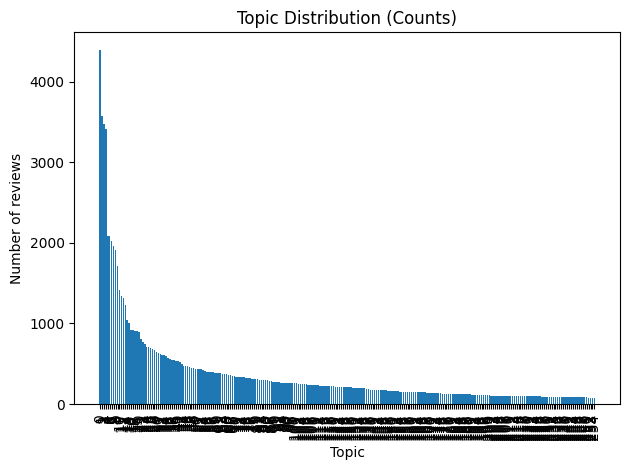

In [5]:
import matplotlib.pyplot as plt

topic_info = topic_model.get_topic_info()

# Remove outlier topic -1 if you want
topic_info_plot = topic_info[topic_info["Topic"] != -1].copy()

plt.figure()
plt.bar(topic_info_plot["Topic"].astype(str), topic_info_plot["Count"])
plt.title("Topic Distribution (Counts)")
plt.xlabel("Topic")
plt.ylabel("Number of reviews")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [8]:
fig = topic_model.visualize_barchart(top_n_topics=15)
fig.show()


In [15]:
t1 = time.time()
topics_fit, _ = topic_model.fit_transform(docs_fit, embeddings=emb_fit)
print(f"BERTopic fit time: {time.time()-t1:.2f}s")

# ---- 5) Transform ALL docs in batches to get topic per row ----
BATCH = 50_000  # reduce to 20_000 if RAM issues
all_topics = []

t2 = time.time()
for i in range(0, len(docs_all), BATCH):
    batch_docs = docs_all[i:i+BATCH]
    emb = embedder.encode(
        batch_docs, batch_size=64, show_progress_bar=True,
        convert_to_numpy=True, normalize_embeddings=True
    ).astype(np.float16)

    batch_topics, _ = topic_model.transform(batch_docs, embeddings=emb)
    all_topics.extend(batch_topics)

    print(f"Processed {min(i+BATCH, len(docs_all)):,}/{len(docs_all):,}")

print(f"Total transform time: {time.time()-t2:.2f}s")

# ---- 6) Attach to df_clean ----
df_clean = df_clean.reset_index(drop=True)
df_clean["topic"] = all_topics

df_clean[["rating", "parent_asin", "text", "topic"]].head()


2026-01-26 13:16:02,301 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-26 13:20:18,543 - BERTopic - Dimensionality - Completed ✓
2026-01-26 13:20:18,547 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-26 13:20:31,851 - BERTopic - Cluster - Completed ✓
2026-01-26 13:20:31,879 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-26 13:20:47,264 - BERTopic - Representation - Completed ✓


BERTopic fit time: 288.00s


NameError: name 'docs_all' is not defined

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# 1-star subset (exclude outliers topic=-1 if you prefer)
df1 = df_clean[df_clean["rating"] == 1].copy()

topic_counts = df1["topic"].value_counts()

# Aggregate "word importance among 1-star reviews"
# (topic prevalence * topic word weight)
word_score = defaultdict(float)

for topic_id, cnt in topic_counts.items():
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)  # list of (word, weight)
    if not words:
        continue
    for w, wt in words:
        word_score[w] += float(cnt) * float(wt)

top10 = sorted(word_score.items(), key=lambda x: x[1], reverse=True)[:10]
top_words = [w for w, _ in top10]
top_vals  = [v for _, v in top10]

plt.figure()
plt.bar(top_words, top_vals)
plt.title("Top 10 Topic Words Discussed in 1-Star Reviews (Weighted by Topic Prevalence)")
plt.xlabel("Topic Word / Phrase")
plt.ylabel("Weighted Importance (topic_count × c-TF-IDF weight)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Number of 1-star reviews: {len(df1):,}")


KeyError: 'topic'

# Task
Load and display the `Musical_Instruments.jsonl` file and another JSONL file from the "Amazon_Musicsl" folder in your Google Drive using PySpark.

## Mount Google Drive

### Subtask:
Mount Google Drive to allow PySpark to access the files stored in your 'Amazon_Musicsl' folder.


**Reasoning**:
To mount Google Drive, I need to import the `drive` module from `google.colab` and then call the `mount()` method with the specified path.



In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## Load Musical_Instruments.jsonl

### Subtask:
Load the 'Musical_Instruments.jsonl' file into a PySpark DataFrame from the specified Google Drive path.


**Reasoning**:
To load the 'Musical_Instruments.jsonl' file into a PySpark DataFrame, I need to first initialize a SparkSession, then define the file path, and finally use `spark.read.json()` to load the data.



# Task
Load and display `Musical_Instruments.jsonl` and another JSONL file from the `Amazon_Musicsl` folder in your Google Drive using PySpark.

## Load Musical_Instruments.jsonl

### Subtask:
Load the 'Musical_Instruments.jsonl' file into a PySpark DataFrame from the specified Google Drive path.


**Reasoning**:
To load the 'Musical_Instruments.jsonl' file into a PySpark DataFrame, I will first import SparkSession, then create a SparkSession instance, and finally use spark.read.json() with the provided file_path to load the data into a DataFrame named `df_musical_instruments`.



In [ ]:
from pyspark.sql import SparkSession

# Create a SparkSession instance
spark = SparkSession.builder.appName("MusicalInstrumentsData").getOrCreate()

# Load the JSONL file into a PySpark DataFrame
df_musical_instruments = spark.read.json(file_path)

print("DataFrame 'df_musical_instruments' created successfully.")

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/content/content/gdrive/MyDrive/Amazon_Musical/Musical_Instruments.jsonl. SQLSTATE: 42K03

In [ ]:
from pyspark.sql.functions import col
from pyspark.sql import SparkSession


In [ ]:
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)

In [ ]:
f_path='/content/gdrive/MyDrive/Amazon_Musical/Musical_Instruments.jsonl'

In [ ]:
df_rev = spark.read.jsonl(f_path, header=True, sep=";")

AttributeError: 'DataFrameReader' object has no attribute 'jsonl'